# 1 Setup und Daten laden



In [ ]:
# Install
#pip install pandas numpy matplotlib seaborn huggingface_hub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Moritz Winnemöller\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotting Style
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

print('Setup abgeschlossen!')

Setup abgeschlossen!


In [14]:
from huggingface_hub import snapshot_download
import json, os, glob

print('Lade awesome-tagesschau Datensatz herunter...')
print('(Das kann beim ersten Mal ein paar Minuten dauern)')

local_path = snapshot_download(
    repo_id='stefan-it/awesome-tagesschau',
    repo_type='dataset',
    allow_patterns=['*.json', '*.jsonl'],
)

print(f'Heruntergeladen nach: {local_path}')
print(f'Inhalt: {os.listdir(local_path)[:20]}')

Lade awesome-tagesschau Datensatz herunter...
(Das kann beim ersten Mal ein paar Minuten dauern)


Fetching 21 files: 100%|██████████| 21/21 [00:39<00:00,  1.86s/it]

Heruntergeladen nach: C:\Users\Moritz Winnemöller\.cache\huggingface\hub\datasets--stefan-it--awesome-tagesschau\snapshots\947fe9f3e017d1004fd216f6257af1c8961dfab6
Inhalt: ['2005.jsonl', '2006.jsonl', '2007.jsonl', '2008.jsonl', '2009.jsonl', '2010.jsonl', '2011.jsonl', '2012.jsonl', '2013.jsonl', '2014.jsonl', '2015.jsonl', '2016.jsonl', '2017.jsonl', '2018.jsonl', '2019.jsonl', '2020.jsonl', '2021.jsonl', '2022.jsonl', '2023.jsonl', '2024.jsonl']


In [15]:
# JSONL-Dateien einlesen (eine JSON-Zeile pro Artikel)
jsonl_files = glob.glob(os.path.join(local_path, '**', '*.jsonl'), recursive=True)
if not jsonl_files:
    jsonl_files = glob.glob(os.path.join(local_path, '*.jsonl'))
print(f'Gefunden: {len(jsonl_files)} JSONL-Dateien')

articles = []
errors = 0

for f in sorted(jsonl_files):
    year_name = os.path.basename(f)
    count_before = len(articles)
    with open(f, 'r', encoding='utf-8') as fp:
        for line in fp:
            try:
                data = json.loads(line.strip())
                article = {
                    'sophoraId': data.get('sophoraId', ''),
                    'title': data.get('title', ''),
                    'date': data.get('date', ''),
                    'ressort': data.get('ressort', 'unknown'),
                    'breakingNews': data.get('breakingNews', False),
                    'type': data.get('type', ''),
                    'topline': data.get('topline', ''),
                    'firstSentence': data.get('firstSentence', ''),
                    'tags': [t.get('tag', '') for t in data.get('tags', []) if isinstance(t, dict)],
                    'n_content_blocks': len(data.get('content', [])),
                    'regionId': data.get('regionId', 0),
                }
                text_blocks = [c.get('value', '') for c in data.get('content', []) if isinstance(c, dict) and c.get('type') == 'text']
                article['text_length'] = sum(len(t) for t in text_blocks)
                article['n_text_blocks'] = len(text_blocks)
                articles.append(article)
            except Exception as e:
                errors += 1
    print(f'  {year_name}: {len(articles) - count_before} Artikel')

print(f'\nErfolgreich geladen: {len(articles)} Artikel ({errors} Fehler)')

Gefunden: 21 JSONL-Dateien
  2005.jsonl: 4 Artikel
  2006.jsonl: 211 Artikel
  2007.jsonl: 888 Artikel
  2008.jsonl: 778 Artikel
  2009.jsonl: 1372 Artikel
  2010.jsonl: 1261 Artikel
  2011.jsonl: 1632 Artikel
  2012.jsonl: 1577 Artikel
  2013.jsonl: 1318 Artikel
  2014.jsonl: 1135 Artikel
  2015.jsonl: 1674 Artikel
  2016.jsonl: 1553 Artikel
  2017.jsonl: 1139 Artikel
  2018.jsonl: 1494 Artikel
  2019.jsonl: 2127 Artikel
  2020.jsonl: 2291 Artikel
  2021.jsonl: 1862 Artikel
  2022.jsonl: 3540 Artikel
  2023.jsonl: 11568 Artikel
  2024.jsonl: 13793 Artikel
  2025.jsonl: 5679 Artikel

Erfolgreich geladen: 56896 Artikel (0 Fehler)


In [16]:
df = pd.DataFrame(articles)
print(f'Shape: {df.shape}')
print(f'Spalten: {list(df.columns)}')
df.head(3)

Shape: (56896, 13)
Spalten: ['sophoraId', 'title', 'date', 'ressort', 'breakingNews', 'type', 'topline', 'firstSentence', 'tags', 'n_content_blocks', 'regionId', 'text_length', 'n_text_blocks']


,sophoraId,title,date,ressort,breakingNews,type,topline,firstSentence,tags,n_content_blocks,regionId,text_length,n_text_blocks
0,meldung-ts-3926,"""Die Menschenrechte wurden eklatant verletzt""",2005-12-14T19:44:00.000+01:00,inland,False,story,Interview mit al Masris Anwalt Gnjidic,"Die Frage, wie tief deutsche Behörden in den F...",[Interview],20,0,4625,16
1,meldung-ts-2268,"Tsunami - die ""große Welle im Hafen""",2005-12-12T13:05:00.000+01:00,wissen,False,story,Hintergrund,"Tsunami ist der Begriff für eine Flutwelle, di...","[Stichwort, Tsunami]",5,0,1709,4
2,meldung-ts-3924,Angeblich 437 CIA-Flüge über Deutschland,2005-12-07T15:04:00.000+01:00,inland,False,story,Affäre um US-Geheimdienst,Die Debatte über geheime Anti-Terror-Operation...,[Meldung],14,0,4192,9


# 2 Preprocessing

In [17]:

# Datum parsen
# Das 'date'-Feld hat Format wie: "2006-01-05T11:50:33.204+01:00"
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df['date_only'] = df['date_parsed'].dt.date
df['year'] = df['date_parsed'].dt.year
df['month'] = df['date_parsed'].dt.month
df['weekday'] = df['date_parsed'].dt.day_name()
df['hour'] = df['date_parsed'].dt.hour

# Fehlende Datumswerte prüfen
print(f'Artikel ohne gültiges Datum: {df["date_parsed"].isna().sum()}')
print(f'Zeitraum: {df["date_parsed"].min()} bis {df["date_parsed"].max()}')

Artikel ohne gültiges Datum: 0
Zeitraum: 2005-12-01 09:13:00+00:00 bis 2025-05-31 21:50:39.231000+00:00


In [ ]:
# Tags sind bereits als Liste von Strings extrahiert
df['tags_list'] = df['tags']
df['num_tags'] = df['tags_list'].apply(len)

# Alle Tags sammeln
all_tags = [tag for tags in df['tags_list'] for tag in tags if tag]
tag_counts = Counter(all_tags)
print(f'Anzahl verschiedener Tags: {len(tag_counts)}')
print(f'\nTop 20 Tags:')
for tag, count in tag_counts.most_common(20):
    print(f'  {tag}: {count}')

Anzahl verschiedener Tags: 18402

Top 20 Tags:
  Meldung: 5230
  EU: 4574
  Ukraine: 2903
  USA: 2526
  Russland: 2211
  Israel: 2158
  Trump: 1507
  Liveblog: 1307
  Nahost: 1290
  Coronavirus: 1159
  China: 1147
  Türkei: 828
  Griechenland: 826
  Brexit: 759
  Interview: 737
  Klimawandel: 717
  AfD: 657
  Flüchtlinge: 651
  Eilmeldung: 636
  FAQ: 605


In [19]:
# Ressort-Verteilung
print('Ressort-Verteilung:')
print(df['ressort'].value_counts())

Ressort-Verteilung:
ressort
ausland         21903
wirtschaft      15738
inland          12654
unknown          2786
wissen           1816
investigativ     1011
faktenfinder      934
sport              54
Name: count, dtype: int64


# 3 Deskriptive Statistik

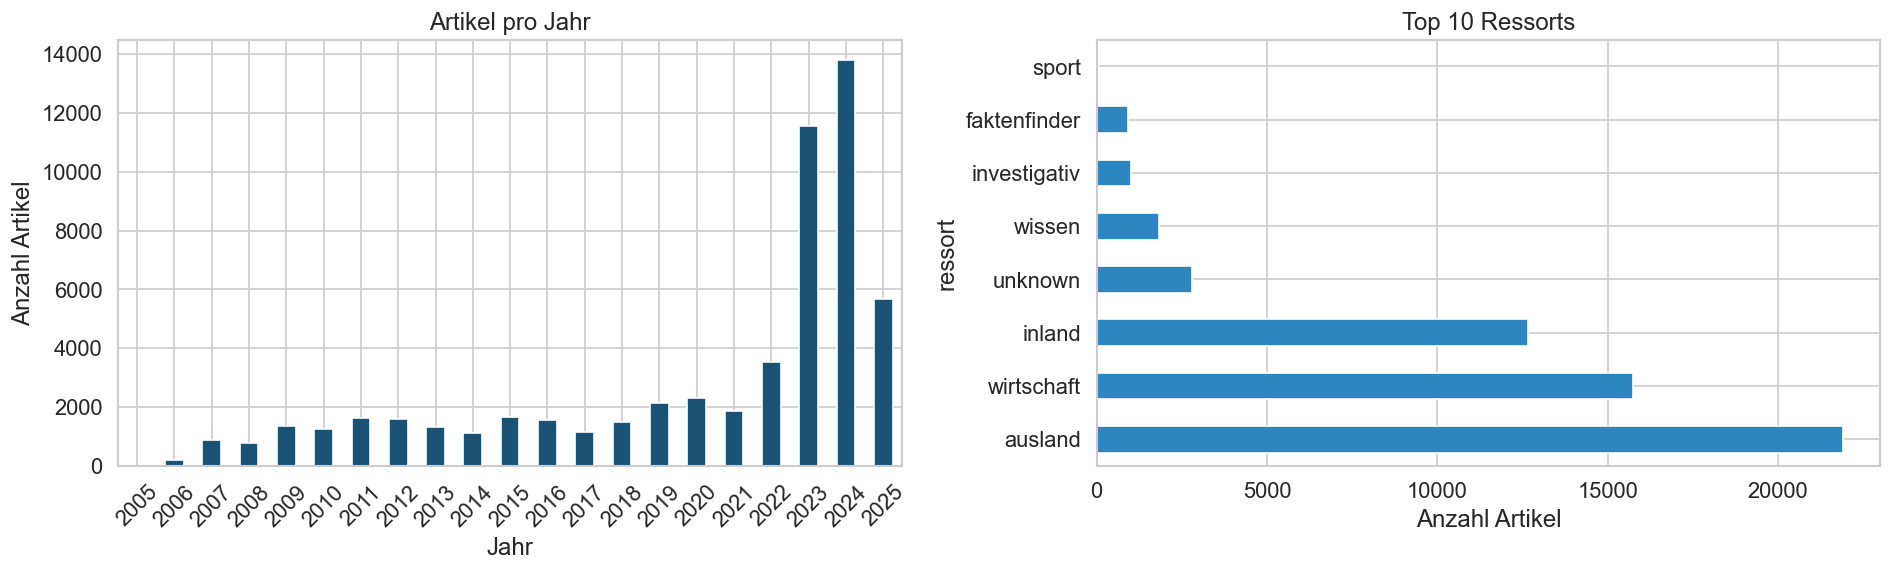

In [20]:
# Artikel pro Jahr
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

articles_per_year = df.groupby('year').size()
articles_per_year.plot(kind='bar', ax=axes[0], color='#1a5276', edgecolor='white')
axes[0].set_title('Artikel pro Jahr')
axes[0].set_xlabel('Jahr')
axes[0].set_ylabel('Anzahl Artikel')
axes[0].tick_params(axis='x', rotation=45)

# Artikel pro Ressort
df['ressort'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#2e86c1')
axes[1].set_title('Top 10 Ressorts')
axes[1].set_xlabel('Anzahl Artikel')

plt.tight_layout()
plt.savefig('01_deskriptive_statistik.png', bbox_inches='tight')
plt.show()

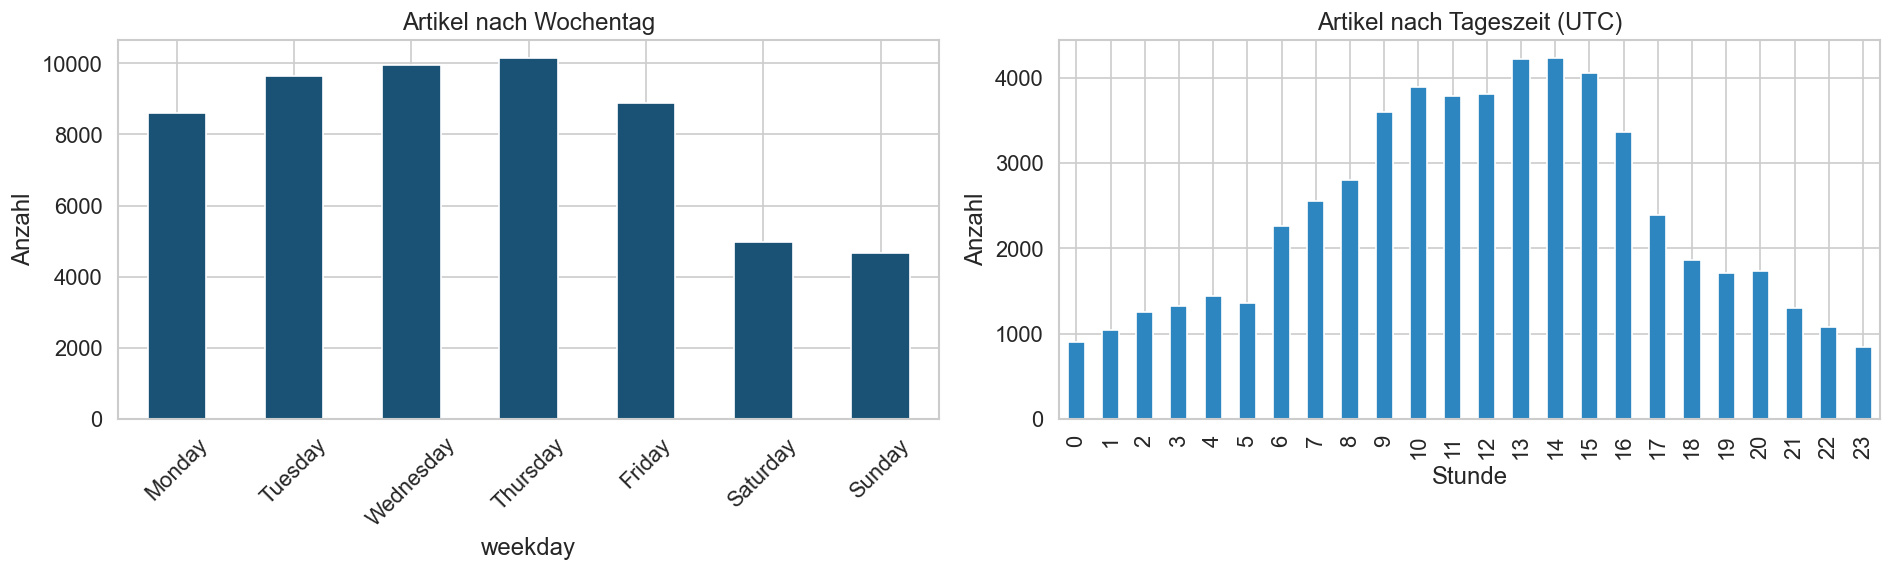

In [21]:
# Veröffentlichungsmuster: Wochentag & Tageszeit
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)
df.groupby('weekday').size().plot(kind='bar', ax=axes[0], color='#1a5276')
axes[0].set_title('Artikel nach Wochentag')
axes[0].set_ylabel('Anzahl')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('hour').size().plot(kind='bar', ax=axes[1], color='#2e86c1')
axes[1].set_title('Artikel nach Tageszeit (UTC)')
axes[1].set_xlabel('Stunde')
axes[1].set_ylabel('Anzahl')

plt.tight_layout()
plt.savefig('02_zeitliche_muster.png', bbox_inches='tight')
plt.show()

# 4 Methode 1: Einfache Gesamt-Lifetime pro Tag

In [22]:
# Tags explodieren: eine Zeile pro (Artikel, Tag)-Kombination
df_tags = df[['date_parsed', 'date_only', 'year', 'tags_list', 'ressort', 'title', 'sophoraId']].explode('tags_list')
df_tags = df_tags.dropna(subset=['tags_list', 'date_parsed'])
df_tags = df_tags[df_tags['tags_list'] != '']  # Leere Tags entfernen
df_tags = df_tags.rename(columns={'tags_list': 'tag'})

print(f'Tag-Artikel-Paare: {len(df_tags)}')
print(f'Einzigartige Tags: {df_tags["tag"].nunique()}')

Tag-Artikel-Paare: 157006
Einzigartige Tags: 18402


In [23]:
# Lifetime pro Tag berechnen
tag_lifetimes = df_tags.groupby('tag').agg(
    first_article=('date_parsed', 'min'),
    last_article=('date_parsed', 'max'),
    num_articles=('sophoraId', 'nunique'),
    num_days_with_articles=('date_only', 'nunique'),
    ressorts=('ressort', lambda x: list(x.unique()))
).reset_index()

tag_lifetimes['lifetime_days'] = (tag_lifetimes['last_article'] - tag_lifetimes['first_article']).dt.total_seconds() / 86400
tag_lifetimes['articles_per_day'] = tag_lifetimes['num_articles'] / tag_lifetimes['lifetime_days'].replace(0, 1)

# Nur Tags mit mindestens 3 Artikeln (um Rauschen zu filtern)
tag_lifetimes_filtered = tag_lifetimes[tag_lifetimes['num_articles'] >= 3].copy()

print(f'Tags mit >= 3 Artikeln: {len(tag_lifetimes_filtered)}')
print(f'\nLifetime-Statistik (in Tagen):')
print(tag_lifetimes_filtered['lifetime_days'].describe())

Tags mit >= 3 Artikeln: 6595

Lifetime-Statistik (in Tagen):
count    6595.000000
mean     2097.232172
std      1925.857143
min         0.000108
25%       572.102420
50%      1335.564979
75%      3430.524693
max      7104.389069
Name: lifetime_days, dtype: float64


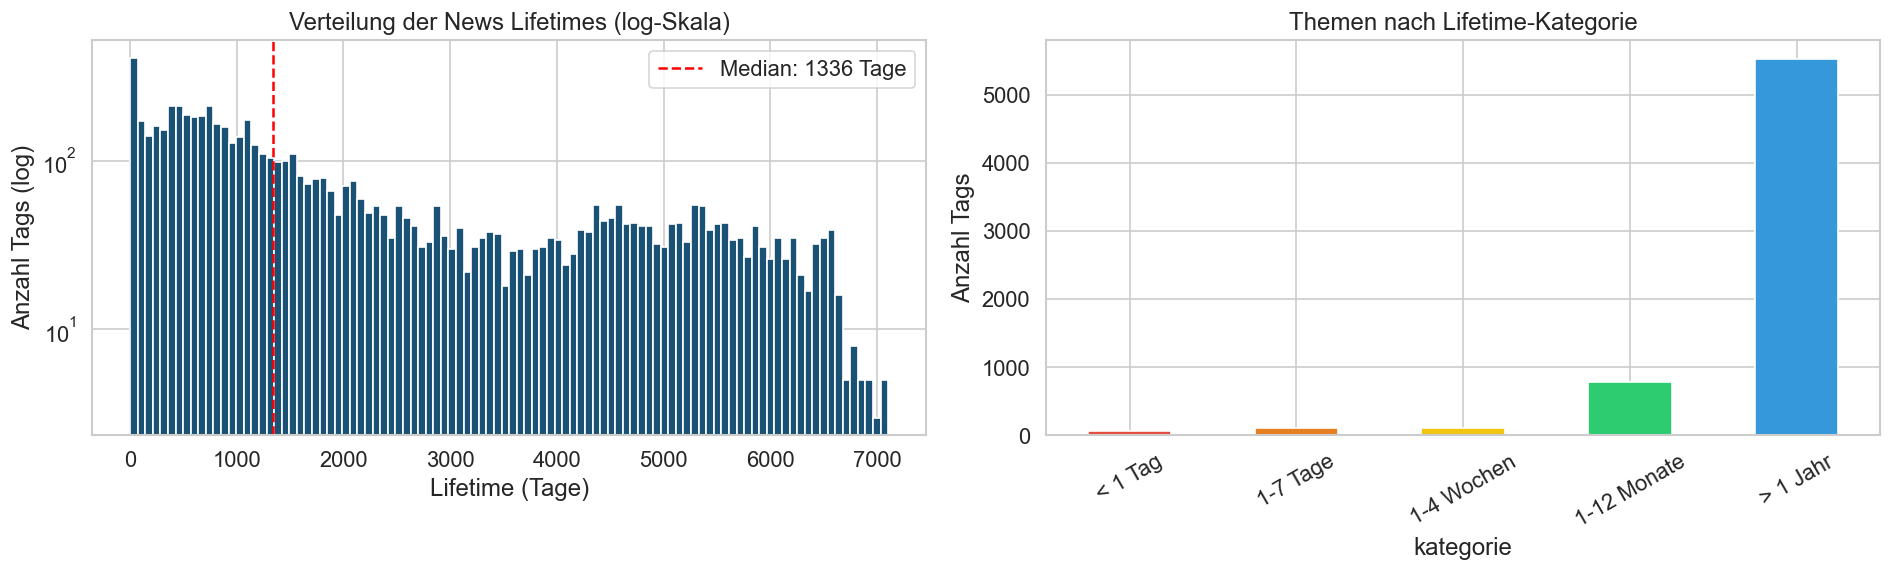

In [24]:
# Visualisierung: Verteilung der Lifetimes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram (log-Skala wegen starker Rechtsschräge)
axes[0].hist(tag_lifetimes_filtered['lifetime_days'], bins=100, color='#1a5276', edgecolor='white', log=True)
axes[0].set_title('Verteilung der News Lifetimes (log-Skala)')
axes[0].set_xlabel('Lifetime (Tage)')
axes[0].set_ylabel('Anzahl Tags (log)')
median_val = tag_lifetimes_filtered['lifetime_days'].median()
axes[0].axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.0f} Tage')
axes[0].legend()

# Kategorien: Eintagsfliegen vs Dauerbrenner
tag_lifetimes_filtered['kategorie'] = pd.cut(
    tag_lifetimes_filtered['lifetime_days'],
    bins=[0, 1, 7, 30, 365, float('inf')],
    labels=['< 1 Tag', '1-7 Tage', '1-4 Wochen', '1-12 Monate', '> 1 Jahr']
)
tag_lifetimes_filtered['kategorie'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
)
axes[1].set_title('Themen nach Lifetime-Kategorie')
axes[1].set_ylabel('Anzahl Tags')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('03_lifetime_verteilung.png', bbox_inches='tight')
plt.show()

In [25]:
# Top 20 langlebigste Themen
print('=== TOP 20 DAUERBRENNER ===')
top_long = tag_lifetimes_filtered.nlargest(20, 'lifetime_days')[['tag', 'lifetime_days', 'num_articles', 'num_days_with_articles']]
for _, row in top_long.iterrows():
    print(f"  {row['tag']}: {row['lifetime_days']:.0f} Tage, {row['num_articles']} Artikel an {row['num_days_with_articles']} Tagen")

print('\n=== TOP 20 INTENSIVSTE THEMEN (Artikel/Tag, mind. 7 Tage) ===')
top_intense = tag_lifetimes_filtered[tag_lifetimes_filtered['lifetime_days'] >= 7].nlargest(20, 'articles_per_day')[['tag', 'articles_per_day', 'num_articles', 'lifetime_days']]
for _, row in top_intense.iterrows():
    print(f"  {row['tag']}: {row['articles_per_day']:.2f} Art/Tag über {row['lifetime_days']:.0f} Tage ({row['num_articles']} Artikel)")

=== TOP 20 DAUERBRENNER ===
  Interview: 7104 Tage, 737 Artikel an 626 Tagen
  DeutschlandTrend: 7097 Tage, 438 Artikel an 426 Tagen
  Israel: 7059 Tage, 2158 Artikel an 780 Tagen
  Iran: 7058 Tage, 555 Artikel an 406 Tagen
  EU: 7034 Tage, 4574 Artikel an 2367 Tagen
  Merkel: 7025 Tage, 301 Artikel an 248 Tagen
  Frankreich: 7015 Tage, 599 Artikel an 443 Tagen
  Vogelgrippe: 6992 Tage, 32 Artikel an 32 Tagen
  Handelsbeziehungen: 6955 Tage, 7 Artikel an 7 Tagen
  Tsunami: 6954 Tage, 10 Artikel an 9 Tagen
  Antisemitismus: 6909 Tage, 141 Artikel an 121 Tagen
  Parlament: 6908 Tage, 46 Artikel an 37 Tagen
  Lobbyismus: 6900 Tage, 18 Artikel an 18 Tagen
  Libanon: 6866 Tage, 229 Artikel an 135 Tagen
  Literatur: 6857 Tage, 18 Artikel an 18 Tagen
  FAQ: 6842 Tage, 605 Artikel an 525 Tagen
  Presseschau: 6841 Tage, 4 Artikel an 4 Tagen
  Rechtsextremismus: 6827 Tage, 198 Artikel an 167 Tagen
  Außenpolitik: 6815 Tage, 18 Artikel an 18 Tagen
  Deutschland: 6802 Tage, 501 Artikel an 431 Tage

# 5 Methode 2: Gap-basierte Lifetime (Berichterstattungsfenster)

In [26]:
def compute_reporting_windows(group, gap_threshold_days=14):
    """Berechnet zusammenhängende Berichterstattungsfenster für ein Tag."""
    dates = sorted(group['date_parsed'].dropna().tolist())
    if len(dates) < 2:
        return [{'duration_days': 0, 'num_articles': len(dates)}]

    windows = []
    window_start = dates[0]
    window_articles = 1
    prev_date = dates[0]

    for d in dates[1:]:
        gap = (d - prev_date).total_seconds() / 86400
        if gap > gap_threshold_days:
            windows.append({
                'duration_days': (prev_date - window_start).total_seconds() / 86400,
                'num_articles': window_articles,
                'start': window_start,
                'end': prev_date
            })
            window_start = d
            window_articles = 1
        else:
            window_articles += 1
        prev_date = d

    # Letztes Fenster
    windows.append({
        'duration_days': (prev_date - window_start).total_seconds() / 86400,
        'num_articles': window_articles,
        'start': window_start,
        'end': prev_date
    })
    return windows

# Auf häufigste Tags anwenden (Top 200)
top_tags = [t for t, c in tag_counts.most_common(200)]
df_top_tags = df_tags[df_tags['tag'].isin(top_tags)]

print('Berechne Berichterstattungsfenster für Top 200 Tags...')
window_results = []
for tag, group in df_top_tags.groupby('tag'):
    windows = compute_reporting_windows(group)
    for w in windows:
        w['tag'] = tag
        window_results.append(w)

df_windows = pd.DataFrame(window_results)
df_windows_filtered = df_windows[df_windows['num_articles'] >= 2]

print(f'Gesamtzahl Berichterstattungsfenster: {len(df_windows_filtered)}')
print(f'\nFenster-Dauer Statistik (Tage):')
print(df_windows_filtered['duration_days'].describe())

Berechne Berichterstattungsfenster für Top 200 Tags...
Gesamtzahl Berichterstattungsfenster: 4734

Fenster-Dauer Statistik (Tage):
count    4734.000000
mean       25.252005
std        71.581503
min         0.000000
25%         4.172511
50%        11.055704
75%        23.741532
max      1823.519562
Name: duration_days, dtype: float64


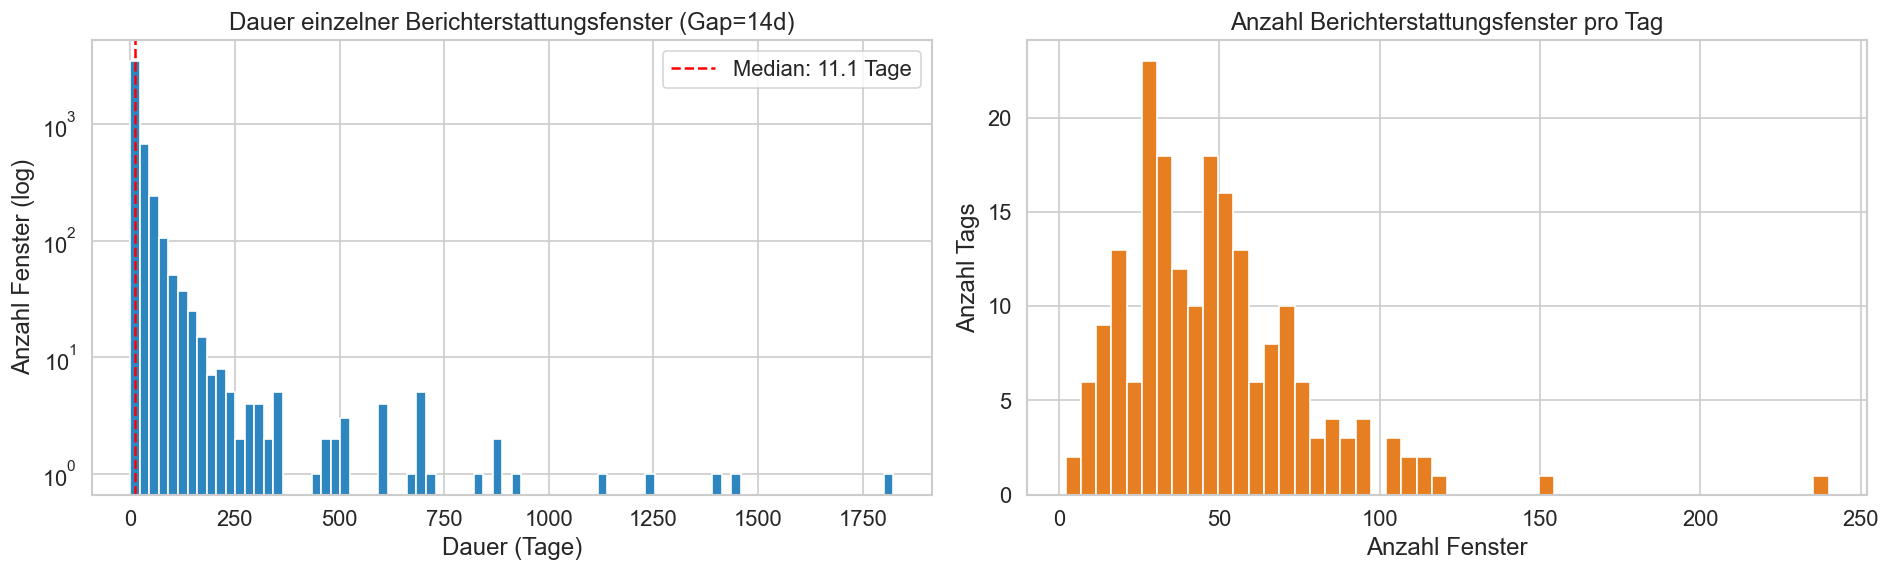

In [27]:
# Vergleich: Einfache Lifetime vs. Gap-basierte Fenster-Dauer
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_windows_filtered['duration_days'], bins=80, color='#2e86c1', edgecolor='white', log=True)
axes[0].set_title('Dauer einzelner Berichterstattungsfenster (Gap=14d)')
axes[0].set_xlabel('Dauer (Tage)')
axes[0].set_ylabel('Anzahl Fenster (log)')
median_w = df_windows_filtered['duration_days'].median()
axes[0].axvline(median_w, color='red', linestyle='--', label=f'Median: {median_w:.1f} Tage')
axes[0].legend()

# Fenster pro Tag: Wie oft taucht ein Thema wieder auf?
windows_per_tag = df_windows.groupby('tag').size()
axes[1].hist(windows_per_tag, bins=50, color='#e67e22', edgecolor='white')
axes[1].set_title('Anzahl Berichterstattungsfenster pro Tag')
axes[1].set_xlabel('Anzahl Fenster')
axes[1].set_ylabel('Anzahl Tags')

plt.tight_layout()
plt.savefig('04_gap_basierte_analyse.png', bbox_inches='tight')
plt.show()

In [28]:
results = {}
for gap in [7, 14, 30]:
    temp_results = []
    for tag, group in df_top_tags.groupby('tag'):
        windows = compute_reporting_windows(group, gap_threshold_days=gap)
        for w in windows:
            temp_results.append(w)
    
    temp_df = pd.DataFrame(temp_results)
    # Nur Fenster mit mindestens 2 Artikeln
    temp_filtered = temp_df[temp_df['num_articles'] >= 2]
    results[gap] = temp_filtered['duration_days'].median()

for g, m in results.items():
    print(f"Gap {g} Tage -> Median Lifetime: {m:.2f} Tage")

Gap 7 Tage -> Median Lifetime: 5.08 Tage
Gap 14 Tage -> Median Lifetime: 11.06 Tage
Gap 30 Tage -> Median Lifetime: 26.19 Tage


# 6 Analyse nach Ressort

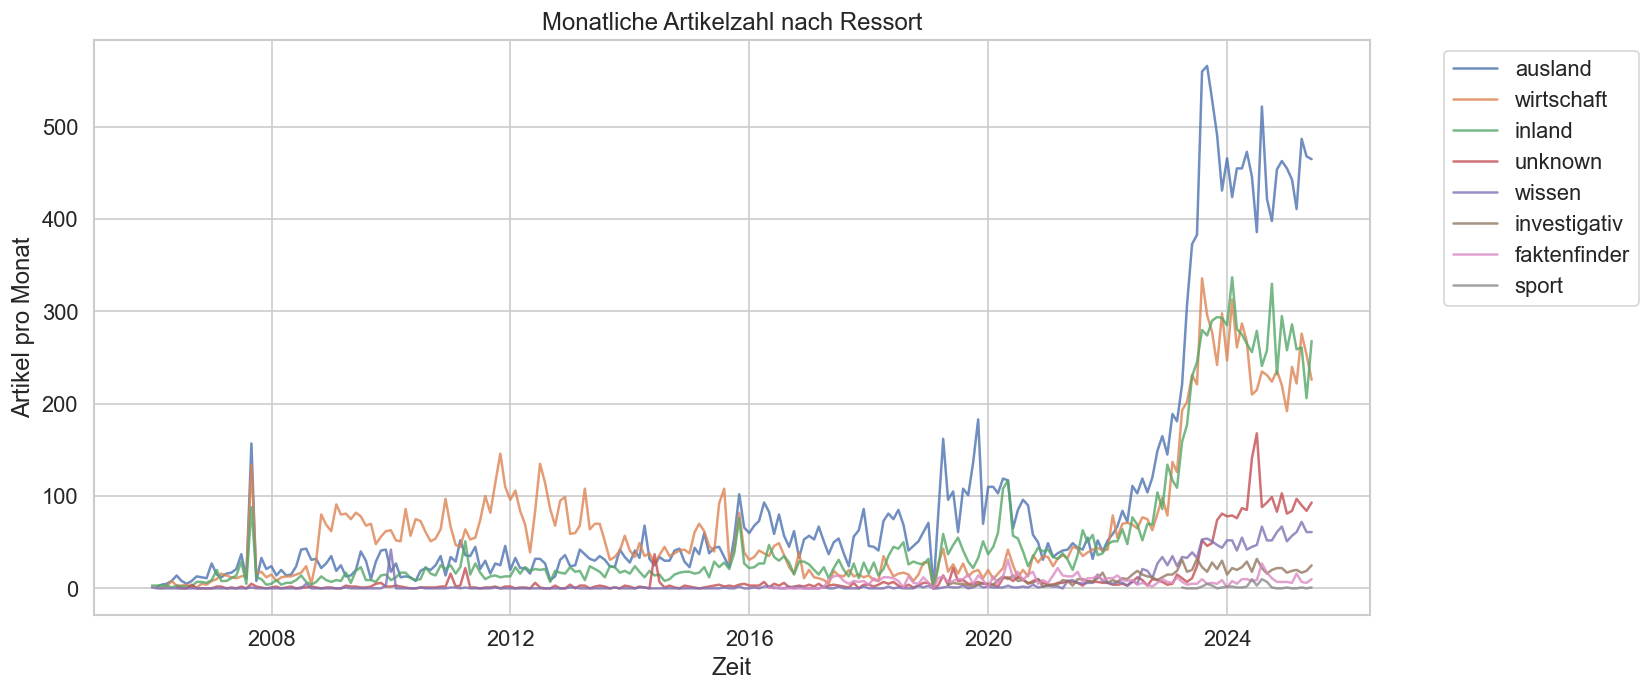

In [29]:
# Monatliche Artikelzahl nach Ressort
top_ressorts = df['ressort'].value_counts().head(8).index.tolist()
ressort_daily = df.groupby(['ressort', 'date_only']).size().reset_index(name='num_articles')

fig, ax = plt.subplots(figsize=(14, 6))
for ressort in top_ressorts:
    data = ressort_daily[ressort_daily['ressort'] == ressort].copy()
    data['date_only'] = pd.to_datetime(data['date_only'])
    data = data.set_index('date_only').resample('M').sum()
    ax.plot(data.index, data['num_articles'], label=ressort, alpha=0.8)

ax.set_title('Monatliche Artikelzahl nach Ressort')
ax.set_xlabel('Zeit')
ax.set_ylabel('Artikel pro Monat')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('05_ressort_zeitverlauf.png', bbox_inches='tight')
plt.show()

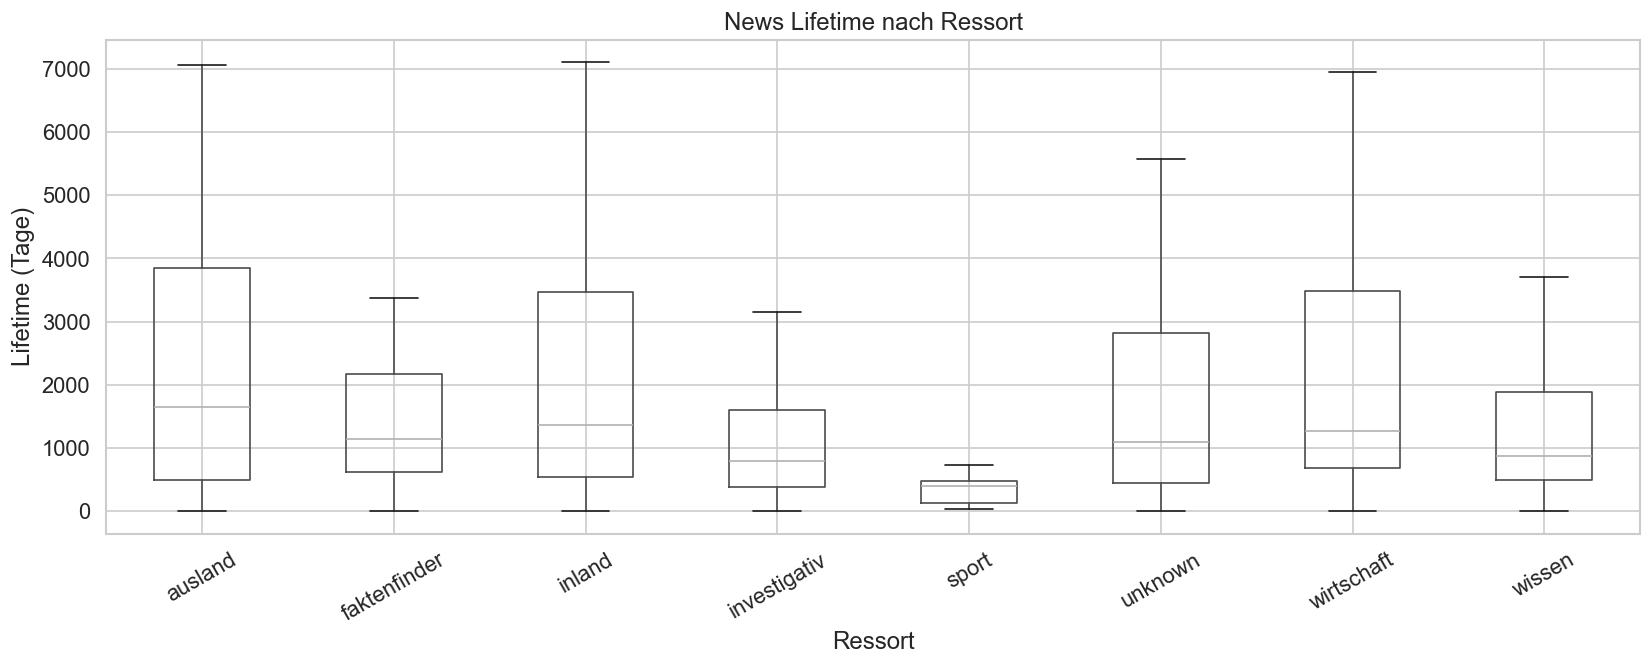

In [30]:
# Tags pro Ressort – Lifetime nach Ressort
tag_ressort = df_tags.groupby('tag')['ressort'].agg(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'
).reset_index()
tag_ressort.columns = ['tag', 'primary_ressort']

tag_lt_with_ressort = tag_lifetimes_filtered.merge(tag_ressort, on='tag', how='left')

# Boxplot: Lifetime nach Ressort
fig, ax = plt.subplots(figsize=(14, 6))
plot_data = tag_lt_with_ressort[tag_lt_with_ressort['primary_ressort'].isin(top_ressorts)]
plot_data.boxplot(column='lifetime_days', by='primary_ressort', ax=ax, showfliers=False)
ax.set_title('News Lifetime nach Ressort')
ax.set_xlabel('Ressort')
ax.set_ylabel('Lifetime (Tage)')
plt.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('06_lifetime_nach_ressort.png', bbox_inches='tight')
plt.show()

# 7 Einzelne Themen im Detail

In [31]:
def plot_topic_timeline(df_tags, topic_keywords, title, ax=None):
    """Visualisiert die Berichterstattungsintensität eines Themas über die Zeit."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))

    mask = df_tags['tag'].str.lower().str.contains(
        '|'.join([k.lower() for k in topic_keywords]), na=False
    )
    topic_articles = df_tags[mask].copy()

    if len(topic_articles) == 0:
        ax.set_title(f'{title} – Keine Artikel gefunden')
        return

    topic_articles['date_only'] = pd.to_datetime(topic_articles['date_only'])
    daily = topic_articles.groupby('date_only')['sophoraId'].nunique().reset_index(name='articles')
    daily = daily.set_index('date_only').resample('W').sum()

    ax.fill_between(daily.index, daily['articles'], alpha=0.3, color='#2e86c1')
    ax.plot(daily.index, daily['articles'], color='#1a5276', linewidth=1)
    ax.set_title(f'{title} ({len(topic_articles)} Tag-Artikel-Paare)')
    ax.set_ylabel('Artikel/Woche')
    return ax

In [32]:
# Erst schauen, welche Tags es wirklich gibt
print('Top 50 Tags im Datensatz:')
for i, (tag, count) in enumerate(tag_counts.most_common(50)):
    print(f'  {i+1:2d}. {tag} ({count})')

Top 50 Tags im Datensatz:
   1. Meldung (5230)
   2. EU (4574)
   3. Ukraine (2903)
   4. USA (2526)
   5. Russland (2211)
   6. Israel (2158)
   7. Trump (1507)
   8. Liveblog (1307)
   9. Nahost (1290)
  10. Coronavirus (1159)
  11. China (1147)
  12. Türkei (828)
  13. Griechenland (826)
  14. Brexit (759)
  15. Interview (737)
  16. Klimawandel (717)
  17. AfD (657)
  18. Flüchtlinge (651)
  19. Eilmeldung (636)
  20. FAQ (605)
  21. Frankreich (599)
  22. Iran (555)
  23. faktenfinder (535)
  24. Migration (531)
  25. Großbritannien (524)
  26. Syrien (508)
  27. Deutschland (501)
  28. Marktbericht (495)
  29. DAX (493)
  30. Inflation (490)
  31. Bundestag (450)
  32. DeutschlandTrend (438)
  33. SPD (433)
  34. Hamas (431)
  35. Italien (417)
  36. Börse (415)
  37. Polen (390)
  38. Olaf Scholz (382)
  39. EZB (354)
  40. Gaza (350)
  41. Investigativ (350)
  42. CDU (346)
  43. Bundeswehr (344)
  44. Biden (338)
  45. Konjunktur (336)
  46. Bundestagswahl 2025 (336)
  47. Put

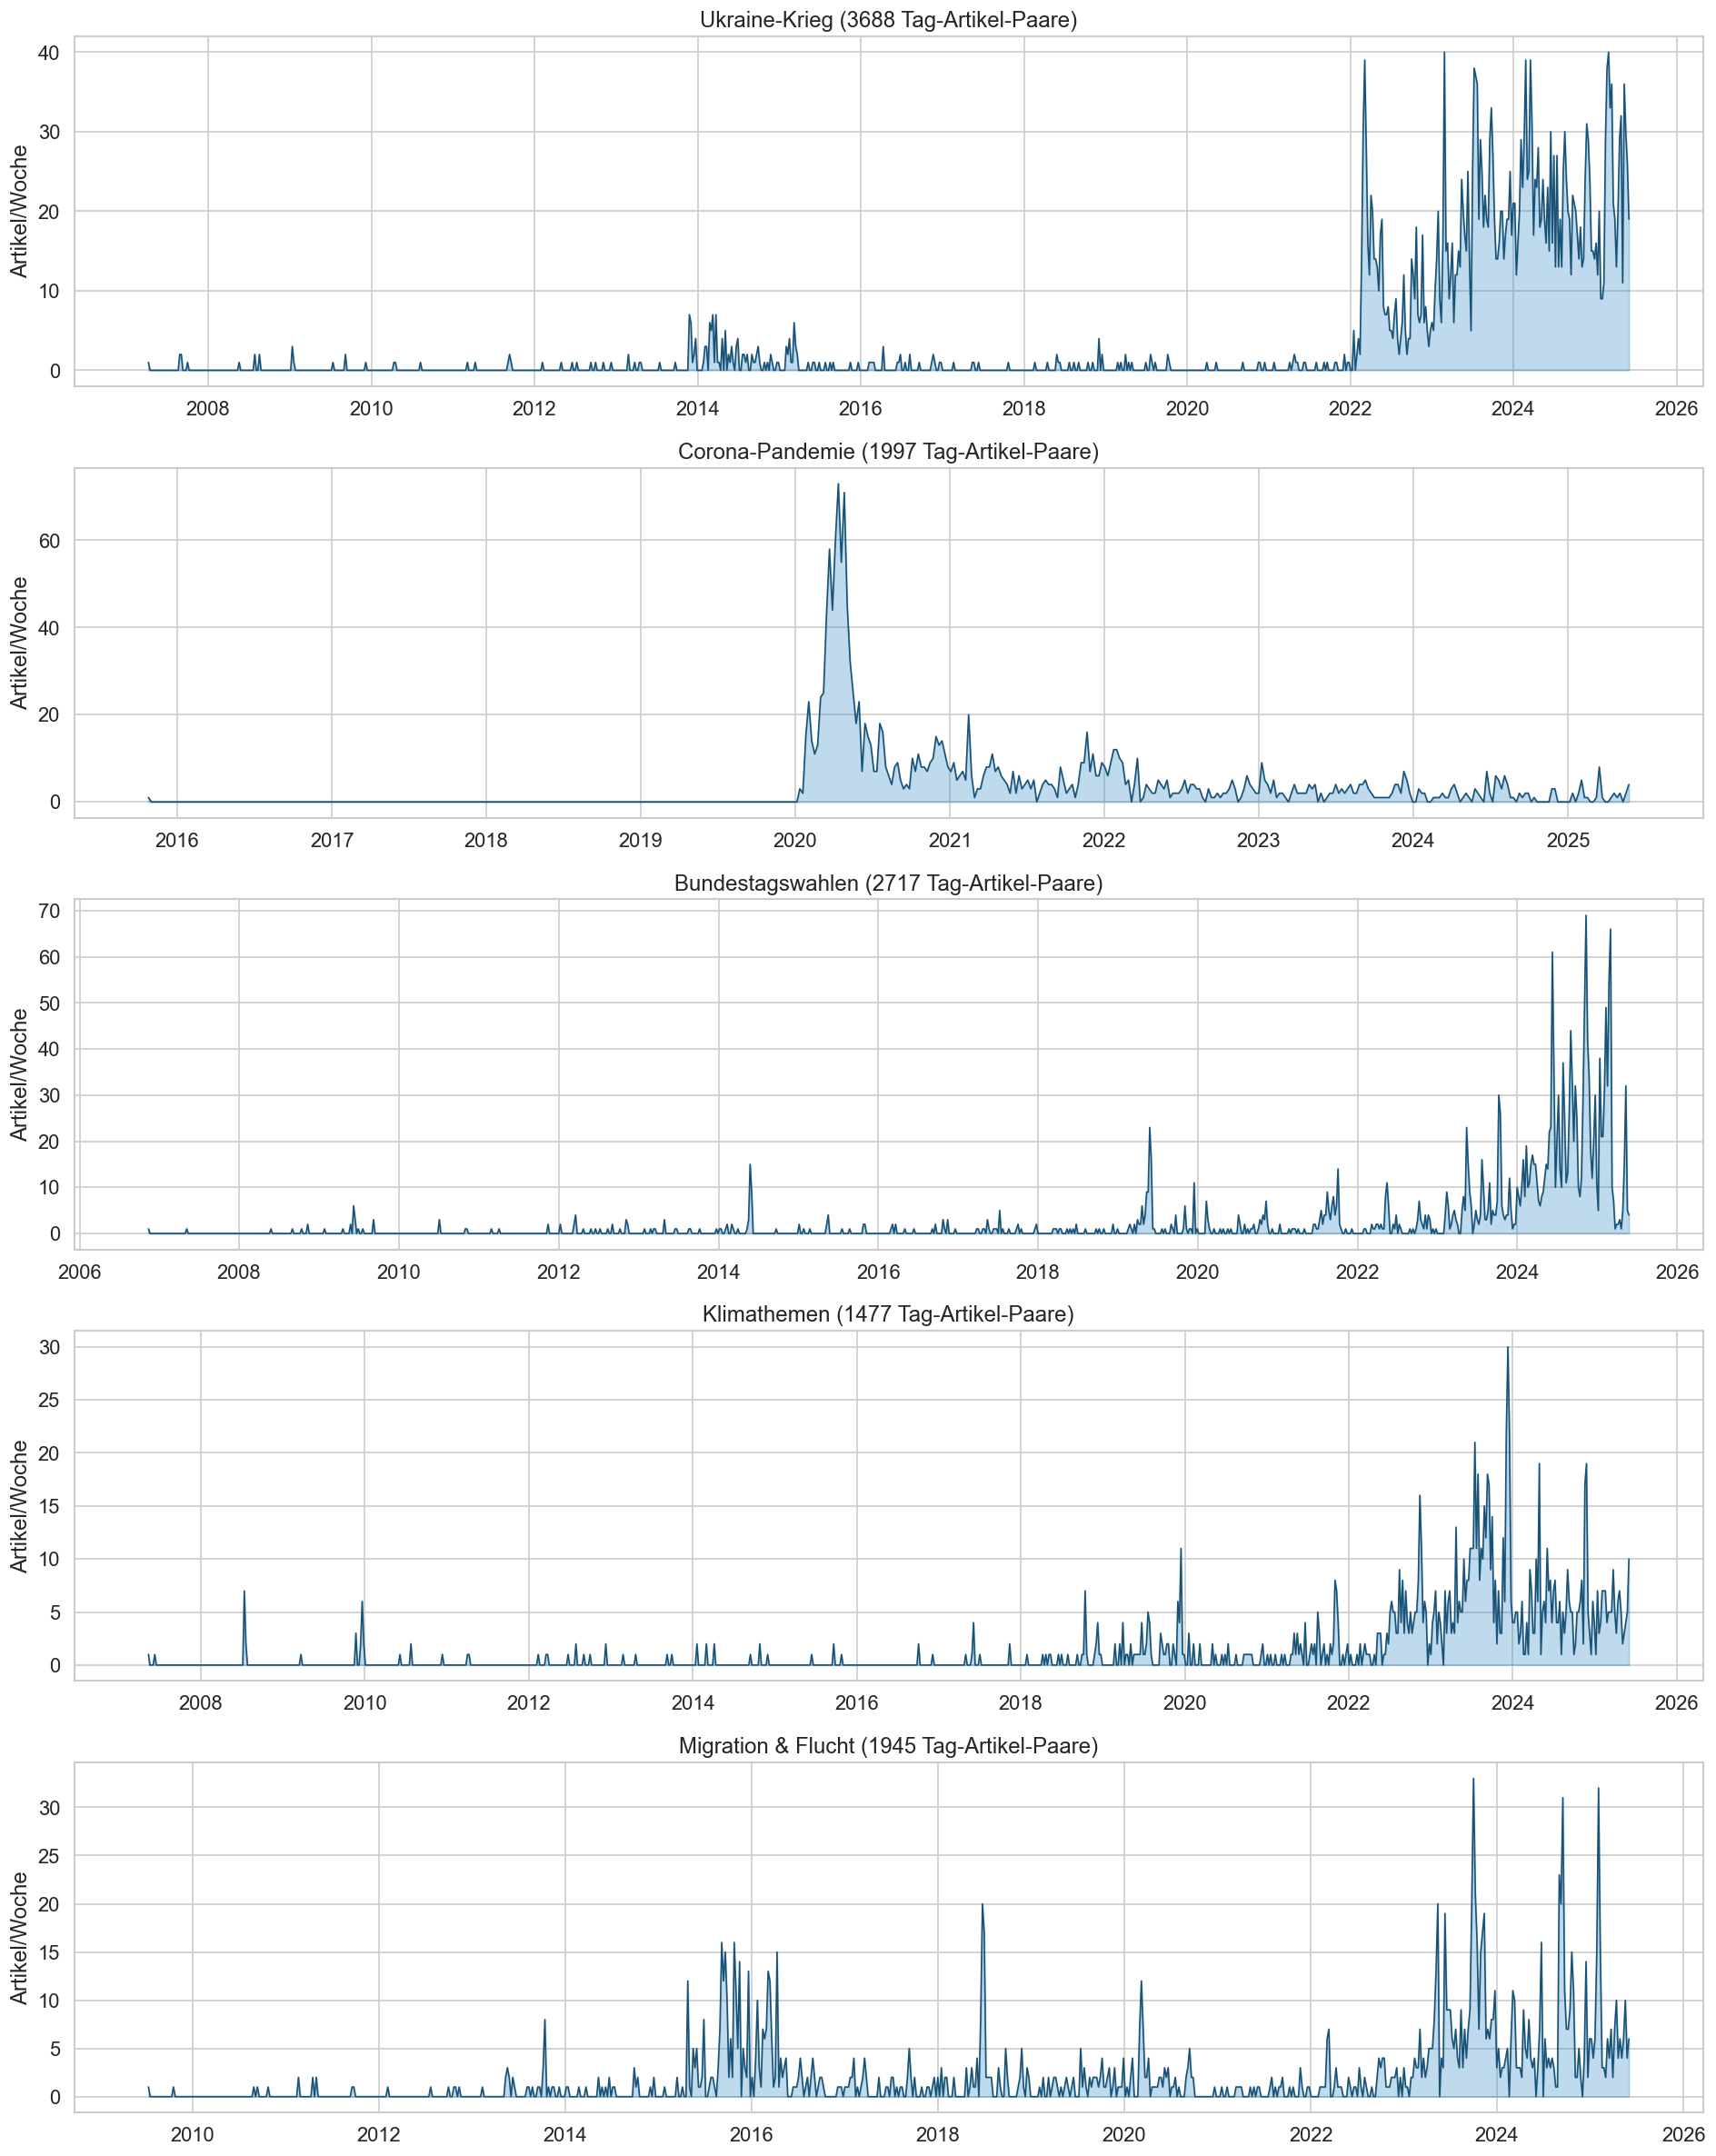

In [33]:
# Fallstudie
case_studies = [
    (['Ukraine', 'Krieg'], 'Ukraine-Krieg'),
    (['Corona', 'COVID', 'Pandemie'], 'Corona-Pandemie'),
    (['Bundestagswahl', 'Wahl'], 'Bundestagswahlen'),
    (['Klima', 'Klimawandel', 'Klimaschutz'], 'Klimathemen'),
    (['Flüchtling', 'Migration', 'Asyl'], 'Migration & Flucht'),
]

fig, axes = plt.subplots(len(case_studies), 1, figsize=(16, 4 * len(case_studies)))
for i, (keywords, title) in enumerate(case_studies):
    plot_topic_timeline(df_tags, keywords, title, ax=axes[i])

plt.tight_layout()
plt.savefig('07_fallstudien_themen.png', bbox_inches='tight')
plt.show()

# 8 Methode 3: Attention Decay

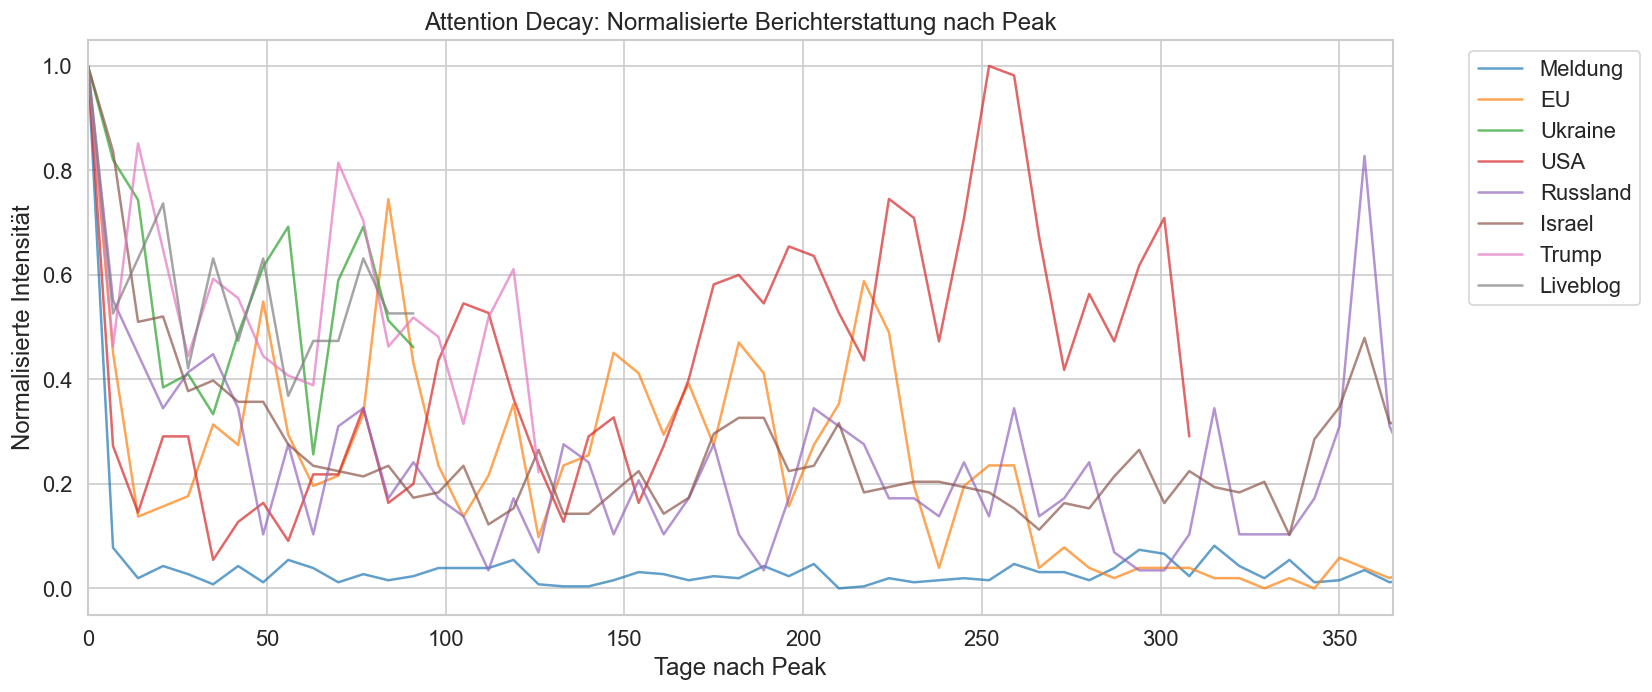

In [34]:
def compute_decay_curve(df_tags, tag_name, resample='D'):
    """Berechnet die normalisierte Decay-Kurve für ein Thema ab dem Peak."""
    articles = df_tags[df_tags['tag'] == tag_name].copy()
    if len(articles) < 10:
        return None

    articles['date_only'] = pd.to_datetime(articles['date_only'])
    daily = articles.groupby('date_only')['sophoraId'].nunique().reset_index(name='articles')
    daily = daily.set_index('date_only').resample(resample).sum().fillna(0)

    peak_idx = daily['articles'].idxmax()
    peak_val = daily.loc[peak_idx, 'articles']
    if peak_val == 0:
        return None

    after_peak = daily.loc[peak_idx:].copy()
    after_peak['days_after_peak'] = (after_peak.index - peak_idx).days
    after_peak['normalized'] = after_peak['articles'] / peak_val

    return after_peak

# Decay-Kurven für die größten Themen
big_tags = tag_lifetimes_filtered.nlargest(30, 'num_articles')['tag'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

plotted = 0
for tag in big_tags:
    decay = compute_decay_curve(df_tags, tag, resample='W')
    if decay is not None and len(decay) > 4:
        ax.plot(decay['days_after_peak'], decay['normalized'],
                label=tag[:25], alpha=0.7, color=colors[plotted % len(colors)])
        plotted += 1
        if plotted >= 8:
            break

ax.set_title('Attention Decay: Normalisierte Berichterstattung nach Peak')
ax.set_xlabel('Tage nach Peak')
ax.set_ylabel('Normalisierte Intensität')
ax.set_xlim(0, 365)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('08_attention_decay.png', bbox_inches='tight')
plt.show()

In [35]:
# Meta-Tags rausfiltern (keine echten Themen)
meta_tags = ['Meldung', 'Liveblog', 'Eilmeldung', 'FAQ', 'Interview',
             'faktenfinder', 'Investigativ', 'Marktbericht', 'Presseschau',
             'DeutschlandTrend', 'Stichwort']

df_tags_clean = df_tags[~df_tags['tag'].isin(meta_tags)]
tag_counts_clean = Counter([t for t in df_tags_clean['tag'] if t])

print("Top 20 Tags (ohne Meta-Tags):")
for tag, count in tag_counts_clean.most_common(20):
    print(f"  {tag}: {count}")

Top 20 Tags (ohne Meta-Tags):
  EU: 4574
  Ukraine: 2903
  USA: 2526
  Russland: 2211
  Israel: 2158
  Trump: 1507
  Nahost: 1290
  Coronavirus: 1159
  China: 1147
  Türkei: 828
  Griechenland: 826
  Brexit: 759
  Klimawandel: 717
  AfD: 657
  Flüchtlinge: 651
  Frankreich: 599
  Iran: 555
  Migration: 531
  Großbritannien: 524
  Syrien: 508


Verfügbare Event-Tags: ['Coronavirus', 'Brexit', 'COP29', 'Ampel-Aus', 'Bundestagswahl 2025', 'Hamas', 'Flüchtlinge', 'Europawahl 2024']



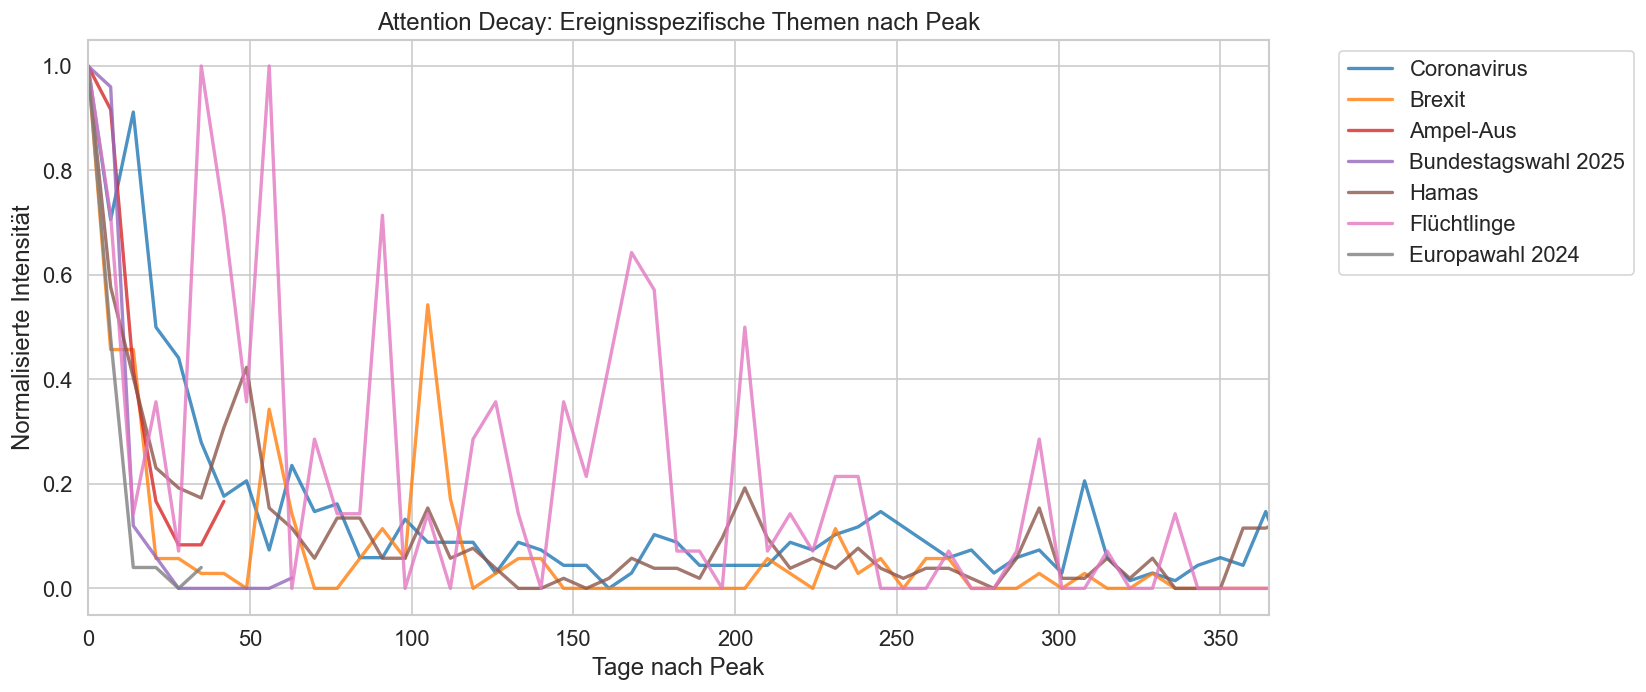

In [36]:
# Attention Decay mit ereignisspezifischen Tags (statt Länder-Dauerthemen)
event_tags = ['Coronavirus', 'Brexit', 'COP29', 'Ampel-Aus',
              'Bundestagswahl 2025', 'Hamas', 'Flüchtlinge', 'Europawahl 2024']

# Nur Tags verwenden, die auch wirklich im Datensatz existieren
available = [t for t in event_tags if t in tag_counts]
print(f"Verfügbare Event-Tags: {available}\n")

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, tag in enumerate(available):
    decay = compute_decay_curve(df_tags, tag, resample='W')
    if decay is not None and len(decay) > 4:
        ax.plot(decay['days_after_peak'], decay['normalized'],
                label=tag, alpha=0.8, linewidth=2, color=colors[i % len(colors)])

ax.set_title('Attention Decay: Ereignisspezifische Themen nach Peak')
ax.set_xlabel('Tage nach Peak')
ax.set_ylabel('Normalisierte Intensität')
ax.set_xlim(0, 365)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('11_attention_decay_events.png', bbox_inches='tight')
plt.show()

# 9 Unterhalb der Aggregationsebene

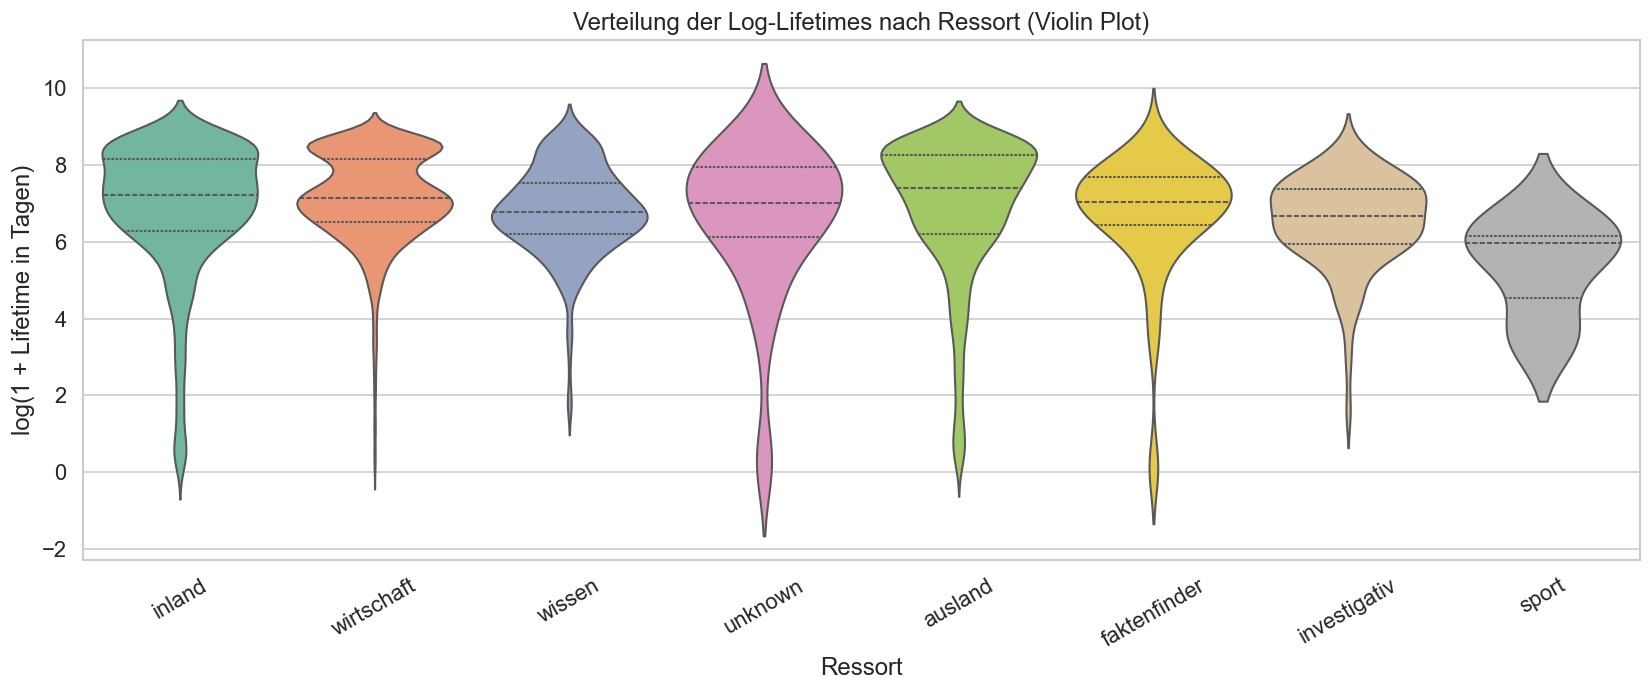

In [37]:
# Violin-Plots: Lifetime-Verteilung pro Ressort
fig, ax = plt.subplots(figsize=(14, 6))

plot_data = tag_lt_with_ressort[tag_lt_with_ressort['primary_ressort'].isin(top_ressorts)].copy()
plot_data['log_lifetime'] = np.log1p(plot_data['lifetime_days'])

sns.violinplot(data=plot_data, x='primary_ressort', y='log_lifetime', ax=ax, palette='Set2', inner='quartile')
ax.set_title('Verteilung der Log-Lifetimes nach Ressort (Violin Plot)')
ax.set_xlabel('Ressort')
ax.set_ylabel('log(1 + Lifetime in Tagen)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('09_violin_ressort.png', bbox_inches='tight')
plt.show()

ValueError: The number of FixedLocator locations (38), usually from a call to set_ticks, does not match the number of labels (76).

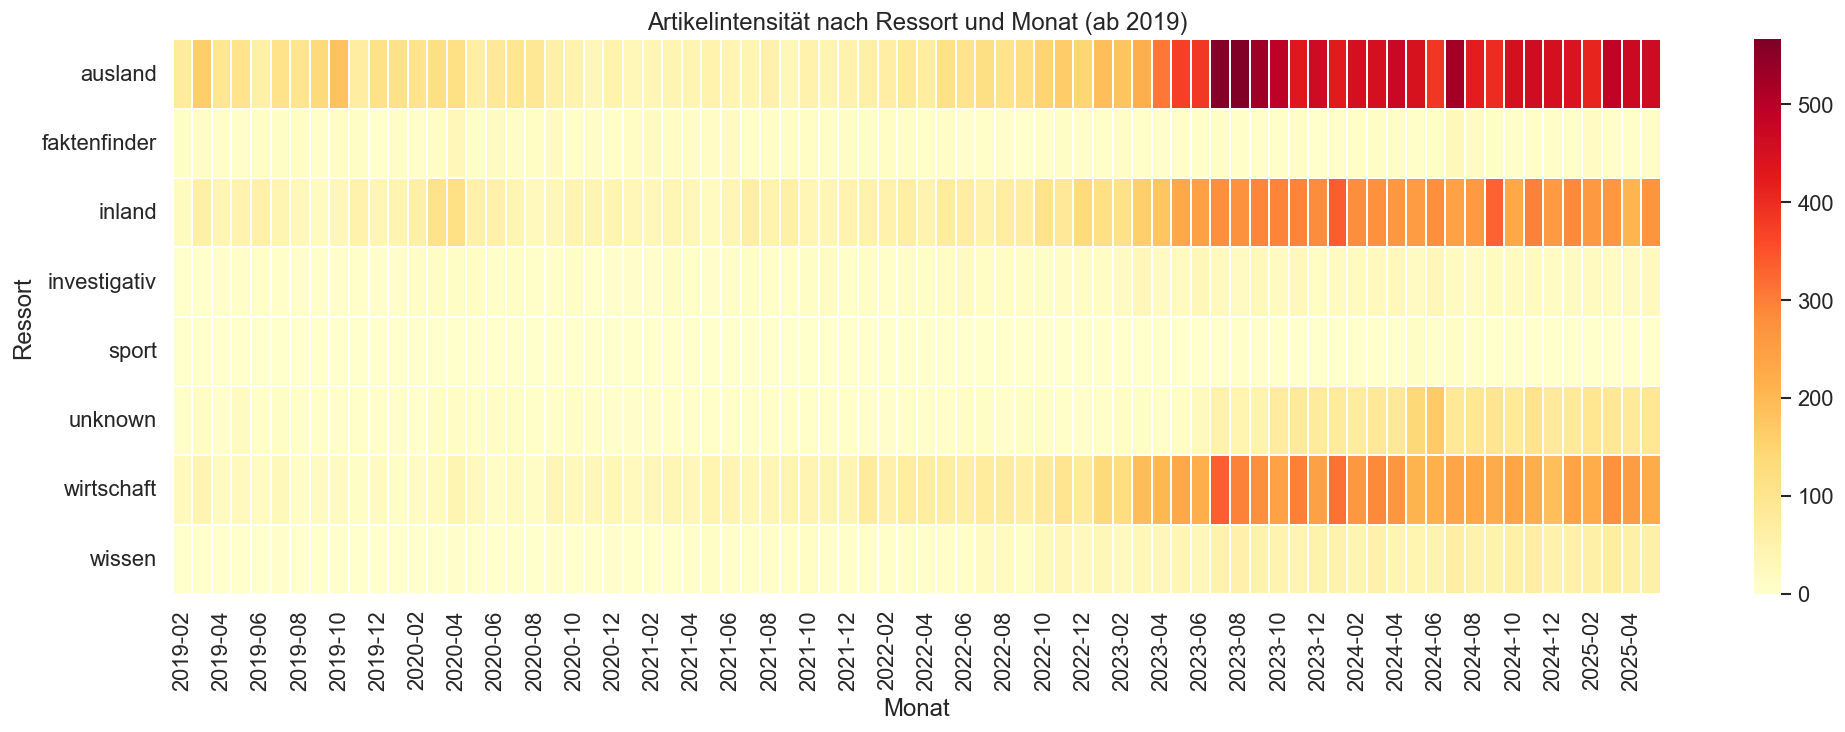

In [38]:
# Heatmap: Artikelintensität nach Monat und Ressort
df_for_heatmap = df[df['ressort'].isin(top_ressorts) & (df['year'] >= 2019)].copy()
df_for_heatmap['year_month'] = df_for_heatmap['date_parsed'].dt.to_period('M').astype(str)
heatmap_data = df_for_heatmap.groupby(['ressort', 'year_month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.1)
ax.set_title('Artikelintensität nach Ressort und Monat (ab 2019)')
ax.set_xlabel('Monat')
ax.set_ylabel('Ressort')
xtick_labels = [label if i % 6 == 0 else '' for i, label in enumerate(heatmap_data.columns)]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('10_heatmap_ressort_monat.png', bbox_inches='tight')
plt.show()

# 10 Zusammenfassung der Ergebnisse

In [39]:
# Zusammenfassung der Ergebnisse
print('=' * 60)
print('ZUSAMMENFASSUNG DER ERGEBNISSE')
print('=' * 60)
print(f'\nDatensatz: {len(df)} Artikel ({df["year"].min()}-{df["year"].max()})')
print(f'Analysierte Tags (>=3 Artikel): {len(tag_lifetimes_filtered)}')
print(f'\nLifetime-Statistik (einfach, in Tagen):')
print(f'  Median: {tag_lifetimes_filtered["lifetime_days"].median():.0f} Tage')
print(f'  Mittelwert: {tag_lifetimes_filtered["lifetime_days"].mean():.0f} Tage')
print(f'  Std: {tag_lifetimes_filtered["lifetime_days"].std():.0f} Tage')
print(f'\nLifetime-Statistik (gap-basiert, Fenster in Tagen):')
print(f'  Median: {df_windows_filtered["duration_days"].median():.1f} Tage')
print(f'  Mittelwert: {df_windows_filtered["duration_days"].mean():.1f} Tage')
print(f'\nKategorien (einfache Lifetime):')
for cat, count in tag_lifetimes_filtered['kategorie'].value_counts().sort_index().items():
    pct = count / len(tag_lifetimes_filtered) * 100
    print(f'  {cat}: {count} Tags ({pct:.1f}%)')
print('\n' + '=' * 60)
print('Plots gespeichert als PNG-Dateien im aktuellen Verzeichnis.')
print('Diese können direkt in die Präsentation übernommen werden.')
print('=' * 60)

ZUSAMMENFASSUNG DER ERGEBNISSE

Datensatz: 56896 Artikel (2005-2025)
Analysierte Tags (>=3 Artikel): 6595

Lifetime-Statistik (einfach, in Tagen):
  Median: 1336 Tage
  Mittelwert: 2097 Tage
  Std: 1926 Tage

Lifetime-Statistik (gap-basiert, Fenster in Tagen):
  Median: 11.1 Tage
  Mittelwert: 25.3 Tage

Kategorien (einfache Lifetime):
  < 1 Tag: 70 Tags (1.1%)
  1-7 Tage: 104 Tags (1.6%)
  1-4 Wochen: 113 Tags (1.7%)
  1-12 Monate: 778 Tags (11.8%)
  > 1 Jahr: 5530 Tags (83.9%)

Plots gespeichert als PNG-Dateien im aktuellen Verzeichnis.
Diese können direkt in die Präsentation übernommen werden.
